# EV Battery ML Project

A complete ML workflow for **Battery Health (%)** and **Remaining Useful Life (cycles)** prediction.

Models include Linear Regression, Ridge, Lasso, Elastic Net, Random Forest, Extra Trees, Gradient Boosting, HistGradientBoosting, and XGBoost when available.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load Dataset

In [2]:
df = pd.read_csv("ev_battery_prediction_dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (42000, 24)


,Battery_Age_Months,Charging_Cycles,Average_Temperature_C,Maximum_Temperature_C,Average_Charging_Time_Hours,Fast_Charging_Frequency_Percent,Average_Discharge_Rate_Percent,Depth_of_Discharge_Percent,Daily_Driving_Distance_KM,Average_Speed_KMH,Regenerative_Braking_Usage_Percent,Battery_Capacity_KWh,Charging_Efficiency_Percent,Discharging_Efficiency_Percent,Number_of_Full_Charges,Number_of_Deep_Discharges,Operating_Hours,Vehicle_Type,Battery_Type,Usage_Type,Charging_Type,Battery_Health_Percentage,Remaining_Useful_Life_Cycles,Battery_Condition
0,35.0,97.0,31.8,46.8,6.68,21.6,10.9,39.9,49.9,33.4,59.0,80.6,95.7,95.7,61.0,4.0,1590.0,NaN,LFP,Personal,AC,89.35,1313.0,Healthy
1,34.0,157.0,32.3,44.2,NaN,14.9,18.2,40.7,49.2,15.0,71.7,55.0,94.0,93.7,97.0,6.0,3150.0,Sedan,NMC,Personal,Mixed,79.79,797.0,Moderate
2,56.0,389.0,20.6,37.7,6.95,9.6,26.1,45.6,80.7,53.1,52.5,NaN,92.7,94.3,220.0,8.0,2885.0,SUV,LFP,Commercial,AC,80.12,1106.0,Healthy
3,37.0,70.0,25.2,42.5,1.31,14.9,20.0,42.6,40.1,43.5,52.8,101.2,98.1,95.0,33.0,4.0,1310.0,SUV,NMC,Personal,Mixed,84.40,1002.0,Healthy
4,15.0,81.0,34.5,47.4,1.28,73.4,20.7,34.1,68.5,26.1,51.2,46.2,93.5,90.9,33.0,4.0,1505.0,Hatchback,NMC,Commercial,DC_Fast,69.22,929.0,Moderate


## 3. First Look

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Battery_Age_Months                  41770 non-null  float64
 1   Charging_Cycles                     41728 non-null  float64
 2   Average_Temperature_C               41673 non-null  float64
 3   Maximum_Temperature_C               41711 non-null  float64
 4   Average_Charging_Time_Hours         41677 non-null  float64
 5   Fast_Charging_Frequency_Percent     41824 non-null  float64
 6   Average_Discharge_Rate_Percent      41775 non-null  float64
 7   Depth_of_Discharge_Percent          41667 non-null  float64
 8   Daily_Driving_Distance_KM           41779 non-null  float64
 9   Average_Speed_KMH                   41723 non-null  float64
 10  Regenerative_Braking_Usage_Percent  41658 non-null  float64
 11  Battery_Capacity_KWh                41754

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Battery_Age_Months,41770.0,NaN,NaN,NaN,40.17321,19.804302,1.0,25.0,39.0,54.0,119.0
Charging_Cycles,41728.0,NaN,NaN,NaN,275.357146,280.479515,20.0,97.0,185.0,350.25,2500.0
Average_Temperature_C,41673.0,NaN,NaN,NaN,27.016298,5.941901,10.0,23.0,27.0,31.0,45.0
Maximum_Temperature_C,41711.0,NaN,NaN,NaN,40.815833,7.587055,20.0,35.5,40.7,45.9,65.0
Average_Charging_Time_Hours,41677.0,NaN,NaN,NaN,2.996297,1.646879,0.5,1.56,2.75,4.24,8.0
Fast_Charging_Frequency_Percent,41824.0,NaN,NaN,NaN,33.857149,24.198724,0.0,14.0,28.6,50.5,99.9
Average_Discharge_Rate_Percent,41775.0,NaN,NaN,NaN,23.63521,8.889593,5.0,17.0,23.2,29.9,57.7
Depth_of_Discharge_Percent,41667.0,NaN,NaN,NaN,41.448261,12.843247,20.0,31.9,40.9,50.2,99.4
Daily_Driving_Distance_KM,41779.0,NaN,NaN,NaN,76.0801,49.491222,9.9,38.8,59.4,101.7,300.0
Average_Speed_KMH,41723.0,NaN,NaN,NaN,41.729928,12.609552,15.0,32.7,41.4,50.1,95.2


In [5]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
Battery_Age_Months                    230
Charging_Cycles                       272
Average_Temperature_C                 327
Maximum_Temperature_C                 289
Average_Charging_Time_Hours           323
Fast_Charging_Frequency_Percent       176
Average_Discharge_Rate_Percent        225
Depth_of_Discharge_Percent            333
Daily_Driving_Distance_KM             221
Average_Speed_KMH                     277
Regenerative_Braking_Usage_Percent    342
Battery_Capacity_KWh                  246
Charging_Efficiency_Percent           269
Discharging_Efficiency_Percent        204
Number_of_Full_Charges                391
Number_of_Deep_Discharges             196
Operating_Hours                       193
Vehicle_Type                          270
Battery_Type                          249
Usage_Type                            252
Charging_Type                         183
Battery_Health_Percentage               0
Remaining_Useful_Life_Cycles            0
Battery_Condition 

## 4. Missing Values

In [6]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


## 5. Remove Duplicates

In [7]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Removed:", before - len(df))
print("New shape:", df.shape)


Removed: 0
New shape: (42000, 24)


## 6. Numeric Features

In [8]:
numeric_features = [
    "Battery_Age_Months",
    "Charging_Cycles",
    "Average_Temperature_C",
    "Maximum_Temperature_C",
    "Average_Charging_Time_Hours",
    "Fast_Charging_Frequency_Percent",
    "Average_Discharge_Rate_Percent",
    "Depth_of_Discharge_Percent",
    "Daily_Driving_Distance_KM",
    "Average_Speed_KMH",
    "Regenerative_Braking_Usage_Percent",
    "Battery_Capacity_KWh",
    "Charging_Efficiency_Percent",
    "Discharging_Efficiency_Percent",
    "Number_of_Full_Charges",
    "Number_of_Deep_Discharges",
    "Operating_Hours"
]

target_columns = [
    "Battery_Health_Percentage",
    "Remaining_Useful_Life_Cycles"
]

numeric_features


['Battery_Age_Months',
 'Charging_Cycles',
 'Average_Temperature_C',
 'Maximum_Temperature_C',
 'Average_Charging_Time_Hours',
 'Fast_Charging_Frequency_Percent',
 'Average_Discharge_Rate_Percent',
 'Depth_of_Discharge_Percent',
 'Daily_Driving_Distance_KM',
 'Average_Speed_KMH',
 'Regenerative_Braking_Usage_Percent',
 'Battery_Capacity_KWh',
 'Charging_Efficiency_Percent',
 'Discharging_Efficiency_Percent',
 'Number_of_Full_Charges',
 'Number_of_Deep_Discharges',
 'Operating_Hours']

## 7. Target Distribution

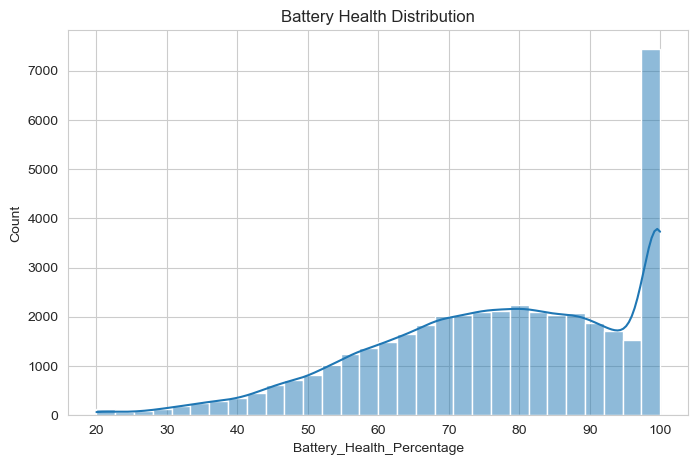

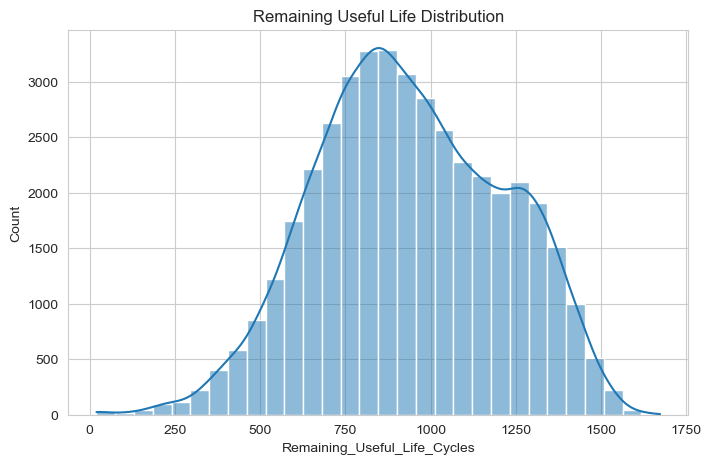

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Battery_Health_Percentage"], bins=30, kde=True)
plt.title("Battery Health Distribution")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["Remaining_Useful_Life_Cycles"], bins=30, kde=True)
plt.title("Remaining Useful Life Distribution")
plt.show()


## 8. Outliers Before

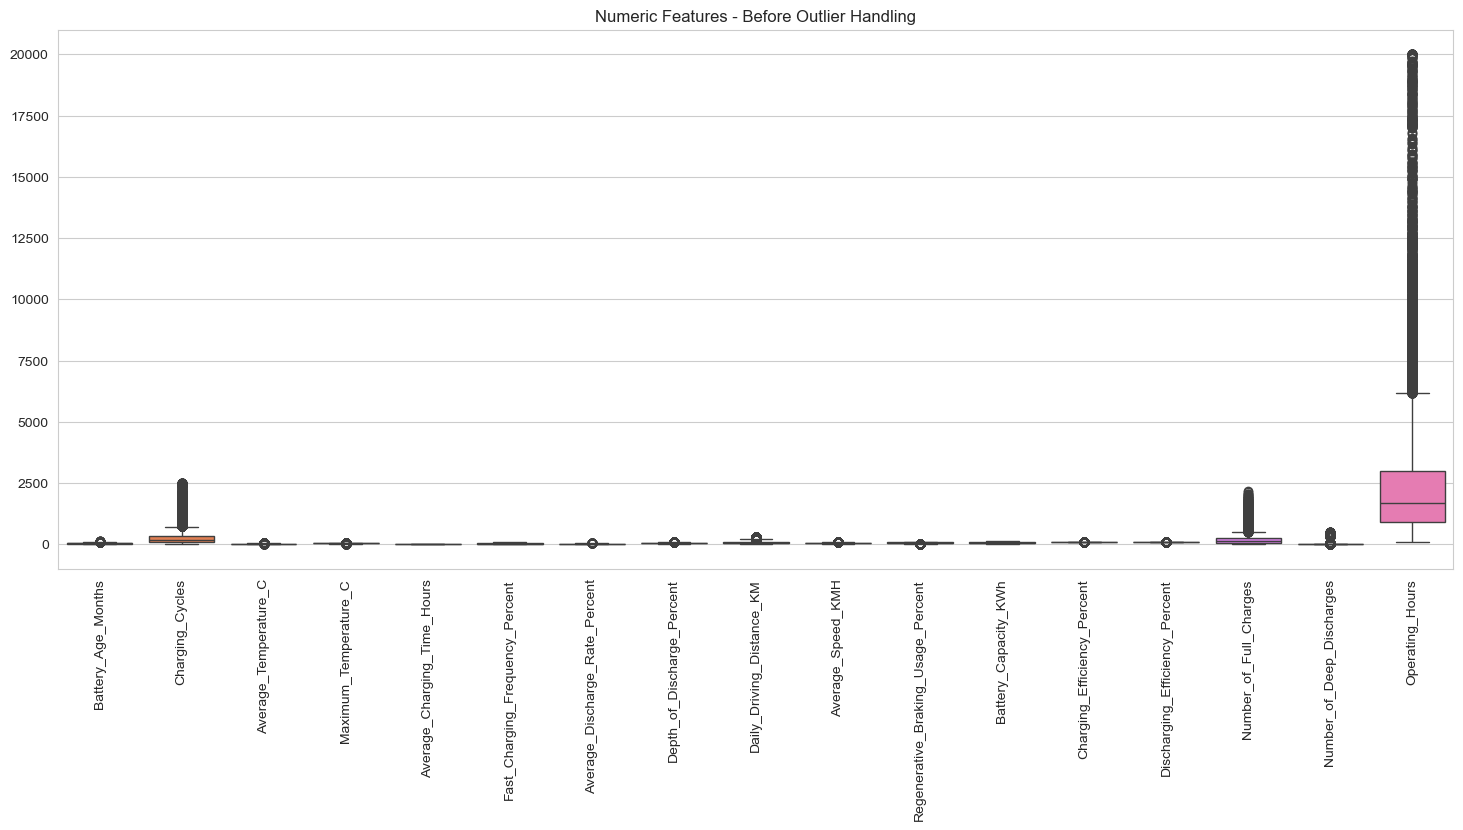

In [10]:
plt.figure(figsize=(18, 7))
sns.boxplot(data=df[numeric_features])
plt.xticks(rotation=90)
plt.title("Numeric Features - Before Outlier Handling")
plt.show()


## 9. Count Outliers

In [11]:
outlier_summary = []

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, count, round(count / len(df) * 100, 2)])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Outlier_Count", "Outlier_Percent"]
).sort_values("Outlier_Count", ascending=False)

outlier_summary


,Feature,Outlier_Count,Outlier_Percent
15,Number_of_Deep_Discharges,3549,8.45
14,Number_of_Full_Charges,2922,6.96
1,Charging_Cycles,2852,6.79
16,Operating_Hours,2732,6.50
8,Daily_Driving_Distance_KM,1247,2.97
13,Discharging_Efficiency_Percent,333,0.79
3,Maximum_Temperature_C,274,0.65
12,Charging_Efficiency_Percent,239,0.57
2,Average_Temperature_C,228,0.54
9,Average_Speed_KMH,208,0.50


## 10. Handle Outliers

In [12]:
# Simple IQR capping: keeps the rows but limits extreme values.

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers capped using IQR limits.")


Outliers capped using IQR limits.


## 11. Outliers After

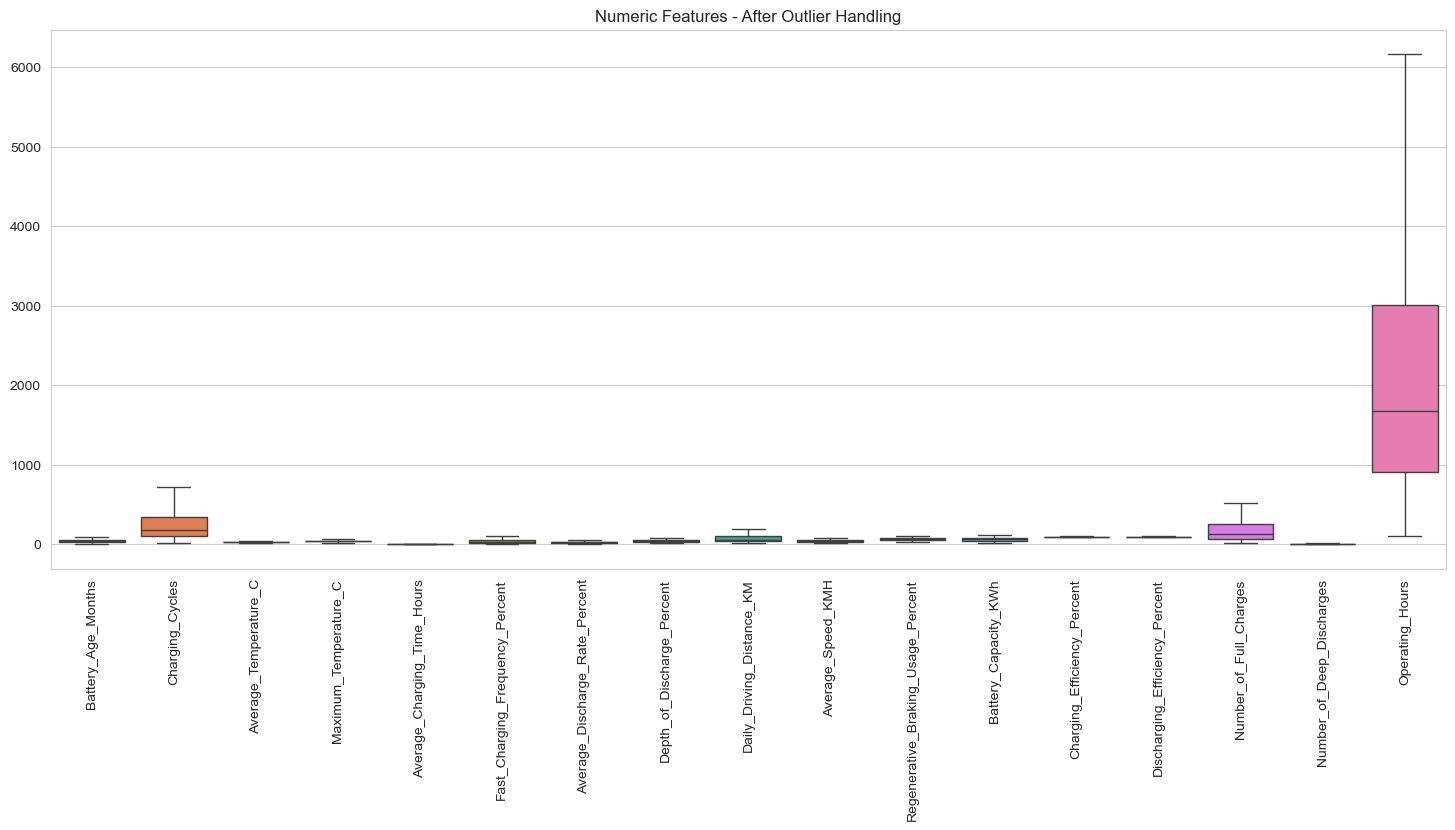

In [13]:
plt.figure(figsize=(18, 7))
sns.boxplot(data=df[numeric_features])
plt.xticks(rotation=90)
plt.title("Numeric Features - After Outlier Handling")
plt.show()


In [14]:
outlier_after = []

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_after.append([col, count])

pd.DataFrame(outlier_after, columns=["Feature", "Remaining_Outliers"])


,Feature,Remaining_Outliers
0,Battery_Age_Months,0
1,Charging_Cycles,0
2,Average_Temperature_C,0
3,Maximum_Temperature_C,0
4,Average_Charging_Time_Hours,0
5,Fast_Charging_Frequency_Percent,0
6,Average_Discharge_Rate_Percent,0
7,Depth_of_Discharge_Percent,0
8,Daily_Driving_Distance_KM,0
9,Average_Speed_KMH,0


## 12. Correlation

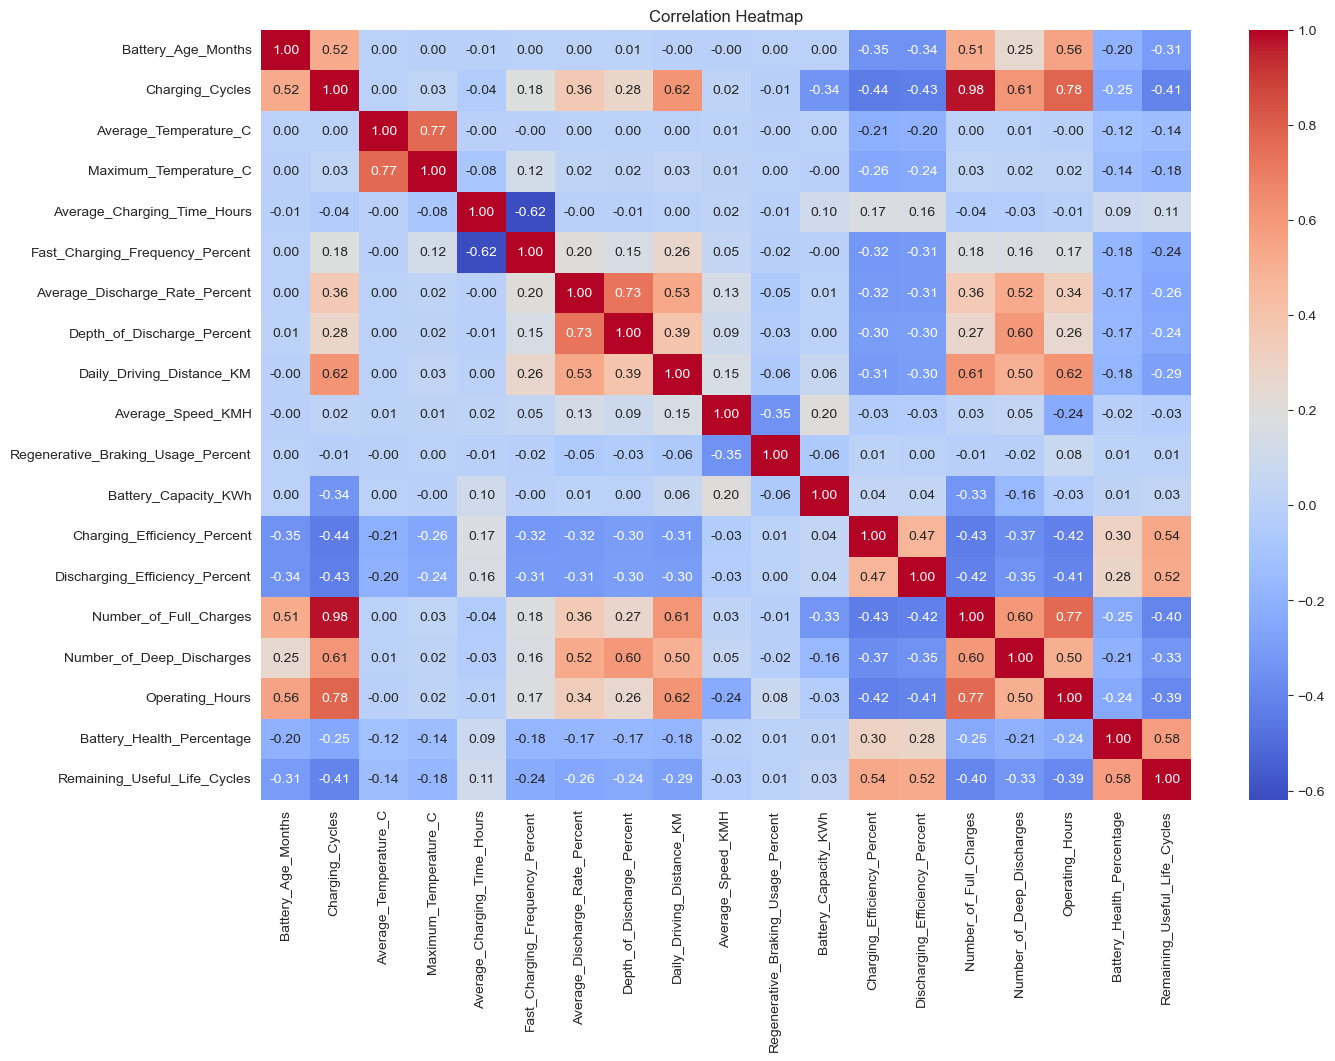

In [15]:
corr = df[numeric_features + target_columns].corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## 13. Important Relationships

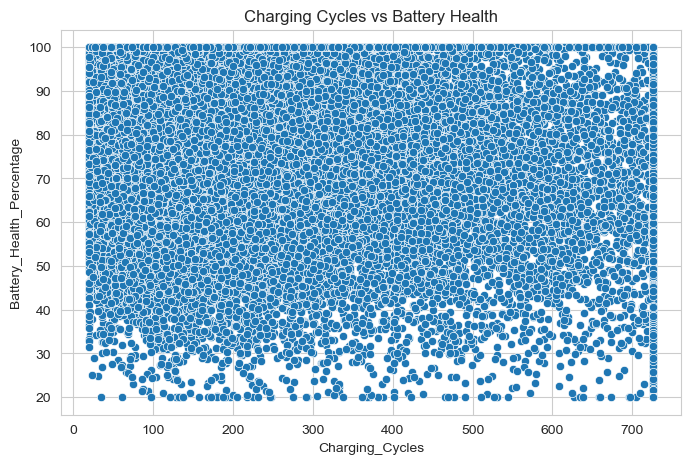

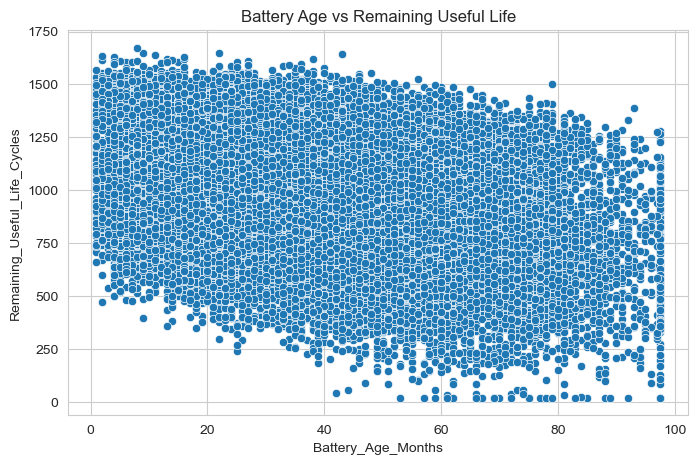

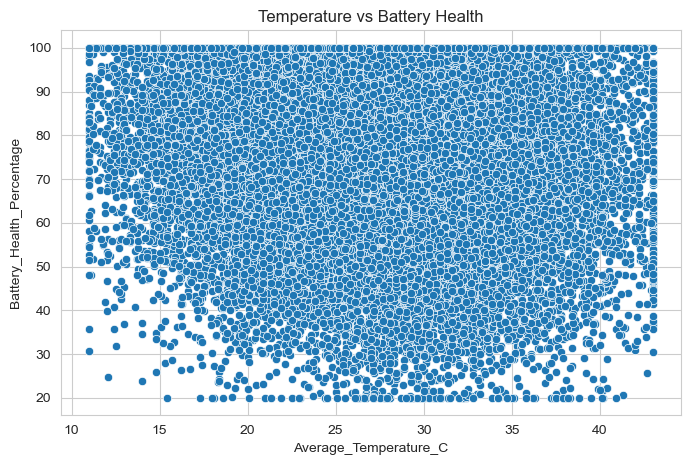

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Charging_Cycles",
    y="Battery_Health_Percentage"
)
plt.title("Charging Cycles vs Battery Health")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Battery_Age_Months",
    y="Remaining_Useful_Life_Cycles"
)
plt.title("Battery Age vs Remaining Useful Life")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Average_Temperature_C",
    y="Battery_Health_Percentage"
)
plt.title("Temperature vs Battery Health")
plt.show()


## 14. Categorical Features

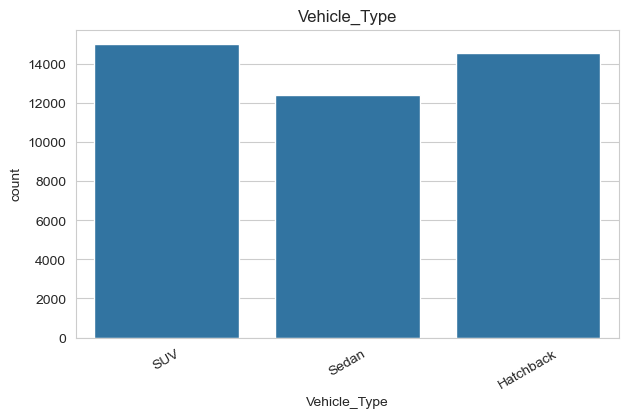

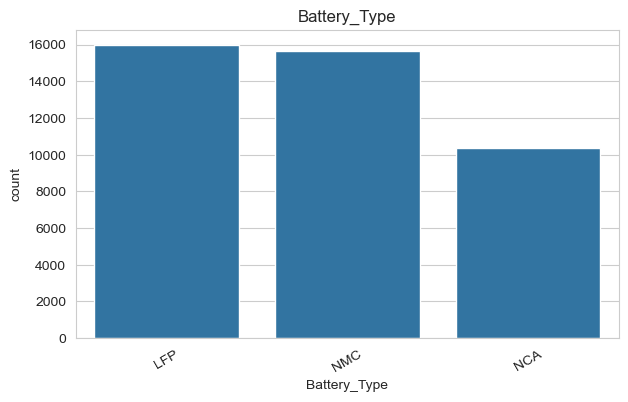

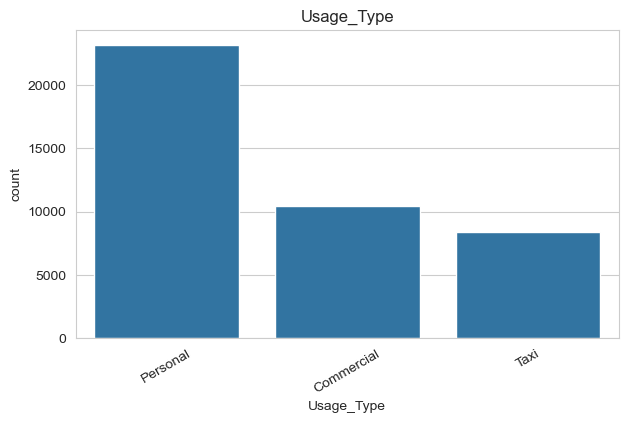

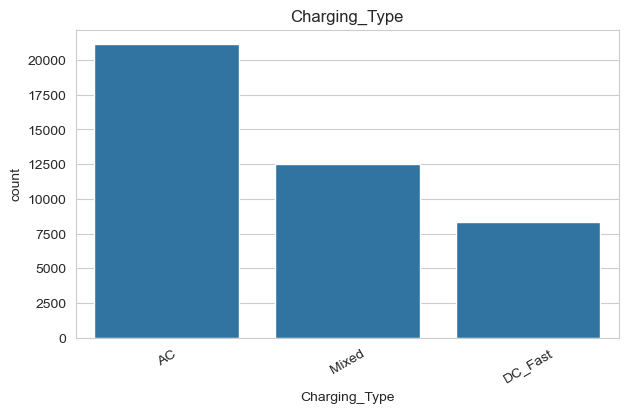

In [17]:
categorical_features = [
    "Vehicle_Type",
    "Battery_Type",
    "Usage_Type",
    "Charging_Type"
]

for col in categorical_features:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=30)
    plt.show()


## 15. Prepare X and y

In [18]:
input_columns = numeric_features + categorical_features

X = df[input_columns].copy()
y_health = df["Battery_Health_Percentage"].copy()
y_rul = df["Remaining_Useful_Life_Cycles"].copy()

print("X shape:", X.shape)
print("Health target:", y_health.shape)
print("RUL target:", y_rul.shape)


X shape: (42000, 21)
Health target: (42000,)
RUL target: (42000,)


## 16. One-Hot Encoding

In [19]:
X = pd.get_dummies(
    X,
    columns=categorical_features,
    dtype=int
)

print("Encoded X shape:", X.shape)
X.head()


Encoded X shape: (42000, 29)


,Battery_Age_Months,Charging_Cycles,Average_Temperature_C,Maximum_Temperature_C,Average_Charging_Time_Hours,Fast_Charging_Frequency_Percent,Average_Discharge_Rate_Percent,Depth_of_Discharge_Percent,Daily_Driving_Distance_KM,Average_Speed_KMH,Regenerative_Braking_Usage_Percent,Battery_Capacity_KWh,Charging_Efficiency_Percent,Discharging_Efficiency_Percent,Number_of_Full_Charges,Number_of_Deep_Discharges,Operating_Hours,Vehicle_Type_Hatchback,Vehicle_Type_SUV,Vehicle_Type_Sedan,Battery_Type_LFP,Battery_Type_NCA,Battery_Type_NMC,Usage_Type_Commercial,Usage_Type_Personal,Usage_Type_Taxi,Charging_Type_AC,Charging_Type_DC_Fast,Charging_Type_Mixed
0,35.0,97.0,31.8,46.8,6.68,21.6,10.9,39.9,49.9,33.4,59.0,80.6,95.7,95.7,61.0,4.0,1590.0,0,1,0,1,0,0,0,1,0,1,0,0
1,34.0,157.0,32.3,44.2,2.75,14.9,18.2,40.7,49.2,15.0,71.7,55.0,94.0,93.7,97.0,6.0,3150.0,0,0,1,0,0,1,0,1,0,0,0,1
2,56.0,389.0,20.6,37.7,6.95,9.6,26.1,45.6,80.7,53.1,52.5,61.0,92.7,94.3,220.0,8.0,2885.0,0,1,0,1,0,0,1,0,0,1,0,0
3,37.0,70.0,25.2,42.5,1.31,14.9,20.0,42.6,40.1,43.5,52.8,101.2,98.1,95.0,33.0,4.0,1310.0,0,1,0,0,0,1,0,1,0,0,0,1
4,15.0,81.0,34.5,47.4,1.28,73.4,20.7,34.1,68.5,26.1,51.2,46.2,93.5,90.9,33.0,4.0,1505.0,1,0,0,0,0,1,1,0,0,0,1,0


## 17. Train Test Split

In [20]:
X_train, X_test, y_health_train, y_health_test, y_rul_train, y_rul_test = train_test_split(
    X,
    y_health,
    y_rul,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (33600, 29)
Test : (8400, 29)


## 18. Evaluation Function

In [21]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


## 19. Linear Regression

In [22]:
linear_health = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_health.fit(X_train, y_health_train)
linear_health_pred = linear_health.predict(X_test)

linear_health_result = evaluate_model(
    "Linear Regression",
    y_health_test,
    linear_health_pred
)

linear_health_result


{'Model': 'Linear Regression',
 'MAE': 13.519043720799193,
 'RMSE': np.float64(16.477562415875365),
 'R2': 0.15875000398345462}

In [23]:
linear_rul = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_rul.fit(X_train, y_rul_train)
linear_rul_pred = linear_rul.predict(X_test)

linear_rul_result = evaluate_model(
    "Linear Regression",
    y_rul_test,
    linear_rul_pred
)

linear_rul_result


{'Model': 'Linear Regression',
 'MAE': 84.09922703928896,
 'RMSE': np.float64(106.7782392246526),
 'R2': 0.849281021968925}

## 20. Ridge Regression

In [24]:
ridge_health = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0))
])

ridge_health.fit(X_train, y_health_train)
ridge_health_pred = ridge_health.predict(X_test)

ridge_health_result = evaluate_model(
    "Ridge",
    y_health_test,
    ridge_health_pred
)

ridge_health_result


{'Model': 'Ridge',
 'MAE': 13.519001126010625,
 'RMSE': np.float64(16.477506189136864),
 'R2': 0.15875574520435132}

In [25]:
ridge_rul = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0))
])

ridge_rul.fit(X_train, y_rul_train)
ridge_rul_pred = ridge_rul.predict(X_test)

ridge_rul_result = evaluate_model(
    "Ridge",
    y_rul_test,
    ridge_rul_pred
)

ridge_rul_result


{'Model': 'Ridge',
 'MAE': 84.10021146723228,
 'RMSE': np.float64(106.77744898962301),
 'R2': 0.8492832528162624}

## 21. Lasso Regression

In [26]:
lasso_health = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01, max_iter=10000))
])

lasso_health.fit(X_train, y_health_train)
lasso_health_pred = lasso_health.predict(X_test)

lasso_health_result = evaluate_model(
    "Lasso",
    y_health_test,
    lasso_health_pred
)

lasso_health_result


{'Model': 'Lasso',
 'MAE': 13.518670686326157,
 'RMSE': np.float64(16.476281915891725),
 'R2': 0.15888074889858272}

In [27]:
lasso_rul = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01, max_iter=10000))
])

lasso_rul.fit(X_train, y_rul_train)
lasso_rul_pred = lasso_rul.predict(X_test)

lasso_rul_result = evaluate_model(
    "Lasso",
    y_rul_test,
    lasso_rul_pred
)

lasso_rul_result


{'Model': 'Lasso',
 'MAE': 84.09857275243562,
 'RMSE': np.float64(106.7772038850673),
 'R2': 0.8492839447473641}

## 22. Elastic Net

In [28]:
elastic_health = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))
])

elastic_health.fit(X_train, y_health_train)
elastic_health_pred = elastic_health.predict(X_test)

elastic_health_result = evaluate_model(
    "Elastic Net",
    y_health_test,
    elastic_health_pred
)

elastic_health_result


{'Model': 'Elastic Net',
 'MAE': 13.518344632212571,
 'RMSE': np.float64(16.476186572078664),
 'R2': 0.15889048353228408}

In [29]:
elastic_rul = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))
])

elastic_rul.fit(X_train, y_rul_train)
elastic_rul_pred = elastic_rul.predict(X_test)

elastic_rul_result = evaluate_model(
    "Elastic Net",
    y_rul_test,
    elastic_rul_pred
)

elastic_rul_result


{'Model': 'Elastic Net',
 'MAE': 84.12043486328434,
 'RMSE': np.float64(106.77394197078155),
 'R2': 0.8492931529926935}

## 23. Random Forest

In [30]:
rf_health = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_health.fit(X_train, y_health_train)
rf_health_pred = rf_health.predict(X_test)

rf_health_result = evaluate_model(
    "Random Forest",
    y_health_test,
    rf_health_pred
)

rf_health_result


{'Model': 'Random Forest',
 'MAE': 13.64979040646335,
 'RMSE': np.float64(16.585414120886107),
 'R2': 0.147701382163561}

In [31]:
rf_rul = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_rul.fit(X_train, y_rul_train)
rf_rul_pred = rf_rul.predict(X_test)

rf_rul_result = evaluate_model(
    "Random Forest",
    y_rul_test,
    rf_rul_pred
)

rf_rul_result


{'Model': 'Random Forest',
 'MAE': 85.21905891042373,
 'RMSE': np.float64(107.42732324399853),
 'R2': 0.8474430702797309}

## 24. Extra Trees

In [32]:
extra_health = ExtraTreesRegressor(
    n_estimators=300,
    max_features=1.0,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

extra_health.fit(X_train, y_health_train)
extra_health_pred = extra_health.predict(X_test)

extra_health_result = evaluate_model(
    "Extra Trees",
    y_health_test,
    extra_health_pred
)

extra_health_result


{'Model': 'Extra Trees',
 'MAE': 13.768033396825397,
 'RMSE': np.float64(16.69987622937254),
 'R2': 0.13589672888213433}

In [33]:
extra_rul = ExtraTreesRegressor(
    n_estimators=300,
    max_features=1.0,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

extra_rul.fit(X_train, y_rul_train)
extra_rul_pred = extra_rul.predict(X_test)

extra_rul_result = evaluate_model(
    "Extra Trees",
    y_rul_test,
    extra_rul_pred
)

extra_rul_result


{'Model': 'Extra Trees',
 'MAE': 85.44479325396827,
 'RMSE': np.float64(107.7956830786505),
 'R2': 0.846395065186204}

## 25. Gradient Boosting

In [34]:
gb_health = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

gb_health.fit(X_train, y_health_train)
gb_health_pred = gb_health.predict(X_test)

gb_health_result = evaluate_model(
    "Gradient Boosting",
    y_health_test,
    gb_health_pred
)

gb_health_result


{'Model': 'Gradient Boosting',
 'MAE': 13.578564069884935,
 'RMSE': np.float64(16.52794350863541),
 'R2': 0.1535977991386288}

In [35]:
gb_rul = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

gb_rul.fit(X_train, y_rul_train)
gb_rul_pred = gb_rul.predict(X_test)

gb_rul_result = evaluate_model(
    "Gradient Boosting",
    y_rul_test,
    gb_rul_pred
)

gb_rul_result


{'Model': 'Gradient Boosting',
 'MAE': 84.08965263796615,
 'RMSE': np.float64(106.2831055421613),
 'R2': 0.8506755574403995}

## 26. HistGradientBoosting

In [36]:
hist_health = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

hist_health.fit(X_train, y_health_train)
hist_health_pred = hist_health.predict(X_test)

hist_health_result = evaluate_model(
    "HistGradientBoosting",
    y_health_test,
    hist_health_pred
)

hist_health_result


{'Model': 'HistGradientBoosting',
 'MAE': 13.60352211811004,
 'RMSE': np.float64(16.54407771657301),
 'R2': 0.15194451487429883}

In [37]:
hist_rul = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

hist_rul.fit(X_train, y_rul_train)
hist_rul_pred = hist_rul.predict(X_test)

hist_rul_result = evaluate_model(
    "HistGradientBoosting",
    y_rul_test,
    hist_rul_pred
)

hist_rul_result


{'Model': 'HistGradientBoosting',
 'MAE': 83.76732887398894,
 'RMSE': np.float64(105.8928147621417),
 'R2': 0.851770236516687}

## 27. XGBoost

In [38]:
try:
    from xgboost import XGBRegressor

    xgb_available = True

    xgb_health = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=2,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    xgb_health.fit(X_train, y_health_train)
    xgb_health_pred = xgb_health.predict(X_test)
    xgb_health_result = evaluate_model(
        "XGBoost",
        y_health_test,
        xgb_health_pred
    )
    xgb_health_result

except ImportError:
    xgb_available = False
    print("XGBoost is not installed. Run: pip install xgboost")


In [39]:
if xgb_available:
    xgb_rul = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=2,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    xgb_rul.fit(X_train, y_rul_train)
    xgb_rul_pred = xgb_rul.predict(X_test)
    xgb_rul_result = evaluate_model(
        "XGBoost",
        y_rul_test,
        xgb_rul_pred
    )
    xgb_rul_result


## 28. Model Comparison - Health

In [40]:
health_results = pd.DataFrame([
    linear_health_result,
    ridge_health_result,
    lasso_health_result,
    elastic_health_result,
    rf_health_result,
    extra_health_result,
    gb_health_result,
    hist_health_result
])

if xgb_available:
    health_results = pd.concat(
        [health_results, pd.DataFrame([xgb_health_result])],
        ignore_index=True
    )

health_results = health_results.sort_values("R2", ascending=False).reset_index(drop=True)
health_results


,Model,MAE,RMSE,R2
0,Elastic Net,13.518345,16.476187,0.158890
1,Lasso,13.518671,16.476282,0.158881
2,Ridge,13.519001,16.477506,0.158756
3,Linear Regression,13.519044,16.477562,0.158750
4,Gradient Boosting,13.578564,16.527944,0.153598
5,XGBoost,13.592998,16.533972,0.152980
6,HistGradientBoosting,13.603522,16.544078,0.151945
7,Random Forest,13.649790,16.585414,0.147701
8,Extra Trees,13.768033,16.699876,0.135897


## 29. Model Comparison - RUL

In [41]:
rul_results = pd.DataFrame([
    linear_rul_result,
    ridge_rul_result,
    lasso_rul_result,
    elastic_rul_result,
    rf_rul_result,
    extra_rul_result,
    gb_rul_result,
    hist_rul_result
])

if xgb_available:
    rul_results = pd.concat(
        [rul_results, pd.DataFrame([xgb_rul_result])],
        ignore_index=True
    )

rul_results = rul_results.sort_values("R2", ascending=False).reset_index(drop=True)
rul_results


,Model,MAE,RMSE,R2
0,XGBoost,83.437892,105.516851,0.852821
1,HistGradientBoosting,83.767329,105.892815,0.851770
2,Gradient Boosting,84.089653,106.283106,0.850676
3,Elastic Net,84.120435,106.773942,0.849293
4,Lasso,84.098573,106.777204,0.849284
5,Ridge,84.100211,106.777449,0.849283
6,Linear Regression,84.099227,106.778239,0.849281
7,Random Forest,85.219059,107.427323,0.847443
8,Extra Trees,85.444793,107.795683,0.846395


## 30. Best Base Models

In [42]:
best_health_name = health_results.iloc[0]["Model"]
best_rul_name = rul_results.iloc[0]["Model"]

print("Best Health model:", best_health_name)
print("Best RUL model:", best_rul_name)


Best Health model: Elastic Net
Best RUL model: XGBoost


## 31. XGBoost Hyperparameter Tuning

In [43]:
if xgb_available:
    param_grid = {
        "n_estimators": [300, 500, 700],
        "learning_rate": [0.02, 0.03, 0.05],
        "max_depth": [3, 4, 5, 6],
        "min_child_weight": [1, 2, 4],
        "subsample": [0.75, 0.85, 1.0],
        "colsample_bytree": [0.75, 0.85, 1.0],
        "reg_alpha": [0, 0.01, 0.05, 0.1],
        "reg_lambda": [1, 2, 5]
    }

    base_xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    random_search_health = RandomizedSearchCV(
        estimator=base_xgb,
        param_distributions=param_grid,
        n_iter=20,
        scoring="r2",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    random_search_health.fit(X_train, y_health_train)

    print("Best Health Parameters:")
    print(random_search_health.best_params_)
    print("Best CV R2:", random_search_health.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Health Parameters:
{'subsample': 0.85, 'reg_lambda': 1, 'reg_alpha': 0.05, 'n_estimators': 300, 'min_child_weight': 2, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.85}
Best CV R2: 0.15649044636755982


## 32. Tuned XGBoost - Health

In [44]:
if xgb_available:
    best_health_model = random_search_health.best_estimator_
    best_health_pred = best_health_model.predict(X_test)

    best_health_result = evaluate_model(
        "Tuned XGBoost",
        y_health_test,
        best_health_pred
    )

    print(best_health_result)


{'Model': 'Tuned XGBoost', 'MAE': 13.57213913668678, 'RMSE': np.float64(16.513132792641105), 'R2': 0.15511404414784646}


## 33. Tune XGBoost - RUL

In [45]:
if xgb_available:
    random_search_rul = RandomizedSearchCV(
        estimator=base_xgb,
        param_distributions=param_grid,
        n_iter=20,
        scoring="r2",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    random_search_rul.fit(X_train, y_rul_train)

    print("Best RUL Parameters:")
    print(random_search_rul.best_params_)
    print("Best CV R2:", random_search_rul.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RUL Parameters:
{'subsample': 0.85, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 700, 'min_child_weight': 2, 'max_depth': 4, 'learning_rate': 0.02, 'colsample_bytree': 0.85}
Best CV R2: 0.8511377953365544


## 34. Tuned XGBoost - RUL

In [46]:
if xgb_available:
    best_rul_model = random_search_rul.best_estimator_
    best_rul_pred = best_rul_model.predict(X_test)

    best_rul_result = evaluate_model(
        "Tuned XGBoost",
        y_rul_test,
        best_rul_pred
    )

    print(best_rul_result)


{'Model': 'Tuned XGBoost', 'MAE': 83.54215491067795, 'RMSE': np.float64(105.52406264068141), 'R2': 0.8528008044194575}


## 35. Final Model Comparison

In [47]:
if xgb_available:
    health_final = pd.concat(
        [health_results, pd.DataFrame([best_health_result])],
        ignore_index=True
    ).sort_values("R2", ascending=False).reset_index(drop=True)

    rul_final = pd.concat(
        [rul_results, pd.DataFrame([best_rul_result])],
        ignore_index=True
    ).sort_values("R2", ascending=False).reset_index(drop=True)
else:
    health_final = health_results.copy()
    rul_final = rul_results.copy()

print("HEALTH")
display(health_final)

print("\nRUL")
display(rul_final)


HEALTH


,Model,MAE,RMSE,R2
0,Elastic Net,13.518345,16.476187,0.158890
1,Lasso,13.518671,16.476282,0.158881
2,Ridge,13.519001,16.477506,0.158756
3,Linear Regression,13.519044,16.477562,0.158750
4,Tuned XGBoost,13.572139,16.513133,0.155114
5,Gradient Boosting,13.578564,16.527944,0.153598
6,XGBoost,13.592998,16.533972,0.152980
7,HistGradientBoosting,13.603522,16.544078,0.151945
8,Random Forest,13.649790,16.585414,0.147701
9,Extra Trees,13.768033,16.699876,0.135897



RUL


,Model,MAE,RMSE,R2
0,XGBoost,83.437892,105.516851,0.852821
1,Tuned XGBoost,83.542155,105.524063,0.852801
2,HistGradientBoosting,83.767329,105.892815,0.851770
3,Gradient Boosting,84.089653,106.283106,0.850676
4,Elastic Net,84.120435,106.773942,0.849293
5,Lasso,84.098573,106.777204,0.849284
6,Ridge,84.100211,106.777449,0.849283
7,Linear Regression,84.099227,106.778239,0.849281
8,Random Forest,85.219059,107.427323,0.847443
9,Extra Trees,85.444793,107.795683,0.846395


## 36. Best Model Scores

In [48]:
best_health_row = health_final.iloc[0]
best_rul_row = rul_final.iloc[0]

print("Best Battery Health Model")
print(best_health_row)

print("\nBest Remaining Useful Life Model")
print(best_rul_row)


Best Battery Health Model
Model    Elastic Net
MAE        13.518345
RMSE       16.476187
R2           0.15889
Name: 0, dtype: object

Best Remaining Useful Life Model
Model       XGBoost
MAE       83.437892
RMSE     105.516851
R2         0.852821
Name: 0, dtype: object


## 37. Actual vs Predicted - Health

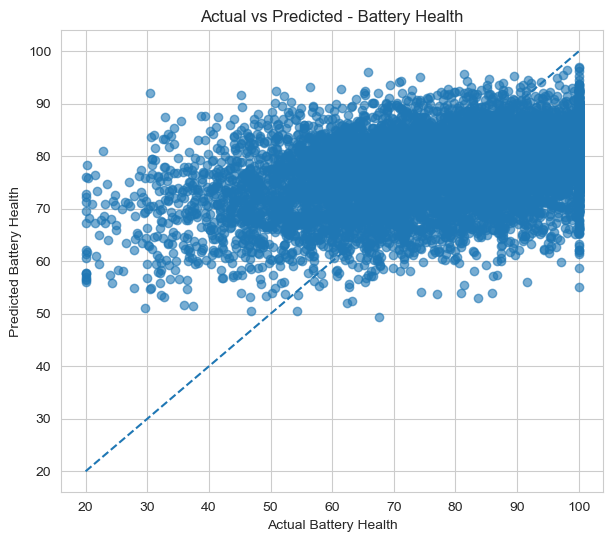

In [49]:
if xgb_available and best_health_row["Model"] == "Tuned XGBoost":
    final_health_pred = best_health_pred
else:
    health_prediction_map = {
        "Linear Regression": linear_health_pred,
        "Ridge": ridge_health_pred,
        "Lasso": lasso_health_pred,
        "Elastic Net": elastic_health_pred,
        "Random Forest": rf_health_pred,
        "Extra Trees": extra_health_pred,
        "Gradient Boosting": gb_health_pred,
        "HistGradientBoosting": hist_health_pred
    }
    final_health_pred = health_prediction_map[best_health_row["Model"]]

plt.figure(figsize=(7, 6))
plt.scatter(y_health_test, final_health_pred, alpha=0.6)
plt.xlabel("Actual Battery Health")
plt.ylabel("Predicted Battery Health")
plt.title("Actual vs Predicted - Battery Health")

min_val = min(y_health_test.min(), final_health_pred.min())
max_val = max(y_health_test.max(), final_health_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()


## 38. Actual vs Predicted - RUL

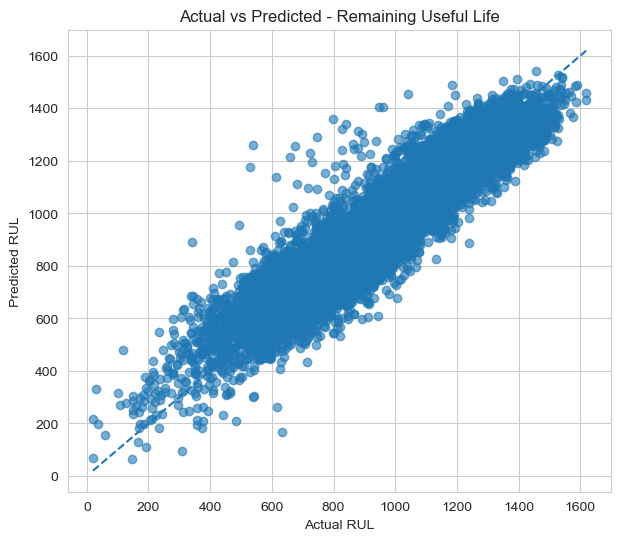

In [52]:
if xgb_available and best_rul_row["Model"] == "Tuned XGBoost":
    final_rul_pred = best_rul_pred
else:
    rul_prediction_map = {
        "Linear Regression": linear_rul_pred,
        "Ridge": ridge_rul_pred,
        "Lasso": lasso_rul_pred,
        "Elastic Net": elastic_rul_pred,
        "Random Forest": rf_rul_pred,
        "Extra Trees": extra_rul_pred,
        "Gradient Boosting": gb_rul_pred,
        "HistGradientBoosting": hist_rul_pred,
        "XGBoost": xgb_rul_pred
    }

    final_rul_pred = rul_prediction_map[best_rul_row["Model"]]

plt.figure(figsize=(7, 6))

plt.scatter(
    y_rul_test,
    final_rul_pred,
    alpha=0.6
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted - Remaining Useful Life")

min_val = min(y_rul_test.min(), final_rul_pred.min())
max_val = max(y_rul_test.max(), final_rul_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.show()

## 39. Residuals

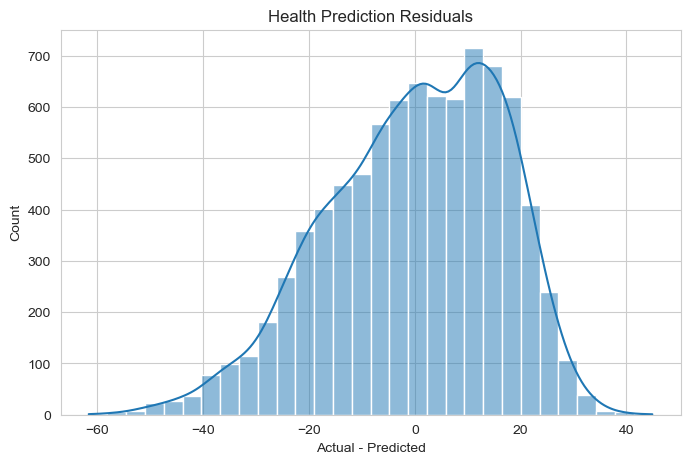

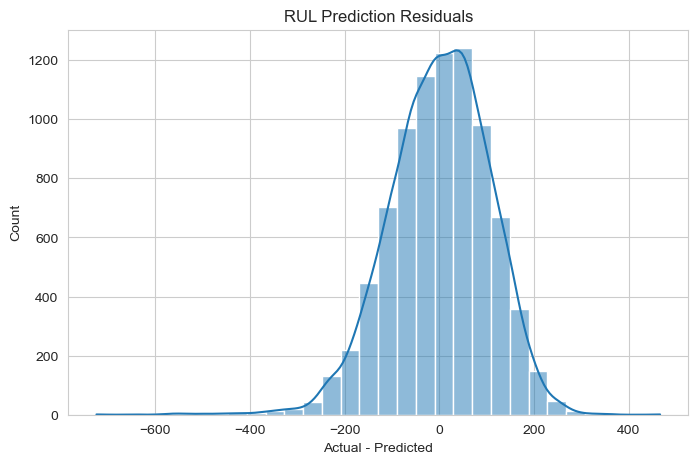

In [53]:
health_residuals = y_health_test - final_health_pred
rul_residuals = y_rul_test - final_rul_pred

plt.figure(figsize=(8, 5))
sns.histplot(health_residuals, kde=True, bins=30)
plt.title("Health Prediction Residuals")
plt.xlabel("Actual - Predicted")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(rul_residuals, kde=True, bins=30)
plt.title("RUL Prediction Residuals")
plt.xlabel("Actual - Predicted")
plt.show()


## 40. Feature Importance

In [54]:
if xgb_available and best_health_row["Model"] == "Tuned XGBoost":
    importance_values = best_health_model.feature_importances_
elif best_health_row["Model"] == "Random Forest":
    importance_values = rf_health.feature_importances_
elif best_health_row["Model"] == "Extra Trees":
    importance_values = extra_health.feature_importances_
elif best_health_row["Model"] == "Gradient Boosting":
    importance_values = gb_health.feature_importances_
else:
    importance_values = None

if importance_values is not None:
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance_values
    }).sort_values("Importance", ascending=False)

    display(feature_importance.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=feature_importance.head(15),
        x="Importance",
        y="Feature"
    )
    plt.title("Top 15 Features for Battery Health")
    plt.show()
else:
    print("Feature importance is not available for the selected linear model.")


Feature importance is not available for the selected linear model.


## 41. Save Best Models

In [57]:
import joblib

# Best Battery Health Model
if xgb_available and best_health_row["Model"] == "Tuned XGBoost":
    health_model_to_save = best_health_model
else:
    health_model_map = {
        "Linear Regression": linear_health,
        "Ridge": ridge_health,
        "Lasso": lasso_health,
        "Elastic Net": elastic_health,
        "Random Forest": rf_health,
        "Extra Trees": extra_health,
        "Gradient Boosting": gb_health,
        "HistGradientBoosting": hist_health,
        "XGBoost": xgb_health
    }

    health_model_to_save = health_model_map[best_health_row["Model"]]


# Best RUL Model
if xgb_available and best_rul_row["Model"] == "Tuned XGBoost":
    rul_model_to_save = best_rul_model
else:
    rul_model_map = {
        "Linear Regression": linear_rul,
        "Ridge": ridge_rul,
        "Lasso": lasso_rul,
        "Elastic Net": elastic_rul,
        "Random Forest": rf_rul,
        "Extra Trees": extra_rul,
        "Gradient Boosting": gb_rul,
        "HistGradientBoosting": hist_rul,
        "XGBoost": xgb_rul
    }

    rul_model_to_save = rul_model_map[best_rul_row["Model"]]


# Save models
joblib.dump(
    health_model_to_save,
    "best_battery_health_model.pkl"
)

joblib.dump(
    rul_model_to_save,
    "best_rul_model.pkl"
)


print("Saved:")
print("best_battery_health_model.pkl")
print("best_rul_model.pkl")

Saved:
best_battery_health_model.pkl
best_rul_model.pkl


## 42. Final Summary

In [58]:
print("EV BATTERY ML PROJECT")
print("=" * 40)

print("\nBattery Health:")
print("Best Model:", best_health_row["Model"])
print("MAE:", round(best_health_row["MAE"], 4))
print("RMSE:", round(best_health_row["RMSE"], 4))
print("R2:", round(best_health_row["R2"], 4))

print("\nRemaining Useful Life:")
print("Best Model:", best_rul_row["Model"])
print("MAE:", round(best_rul_row["MAE"], 4))
print("RMSE:", round(best_rul_row["RMSE"], 4))
print("R2:", round(best_rul_row["R2"], 4))


EV BATTERY ML PROJECT

Battery Health:
Best Model: Elastic Net
MAE: 13.5183
RMSE: 16.4762
R2: 0.1589

Remaining Useful Life:
Best Model: XGBoost
MAE: 83.4379
RMSE: 105.5169
R2: 0.8528


## Accuracy

In [59]:
mape = np.mean(
    np.abs((y_rul_test - final_rul_pred) / y_rul_test)
) * 100

accuracy = 100 - mape

print("RUL Prediction Accuracy:", accuracy, "%")

RUL Prediction Accuracy: 89.27684983637289 %


In [60]:
mape = np.mean(
    np.abs((y_health_test - final_health_pred) / y_health_test)
) * 100

accuracy = 100 - mape

print("Battery Health Prediction Accuracy:", accuracy, "%")

Battery Health Prediction Accuracy: 79.01469287524786 %


## Cross-Validation — Battery Health

In [62]:
from sklearn.model_selection import cross_val_score

health_cv_scores = cross_val_score(
    elastic_health,
    X_train,
    y_health_train,
    cv=5,
    scoring="r2"
)

print("Battery Health - Elastic Net")
print("CV R2 Scores:", health_cv_scores)
print("Mean CV R2:", health_cv_scores.mean())
print("Standard Deviation:", health_cv_scores.std())

Battery Health - Elastic Net
CV R2 Scores: [0.16068765 0.15453391 0.15267197 0.168154   0.16550657]
Mean CV R2: 0.16031082121301177
Standard Deviation: 0.006006297138735353


### Cross-Validation — RUL

In [65]:
rul_cv_scores = cross_val_score(
    xgb_rul,
    X_train,
    y_rul_train,
    cv=5,
    scoring="r2"
)

print("RUL - XGBoost")
print("CV R2 Scores:", rul_cv_scores)
print("Mean CV R2:", rul_cv_scores.mean())
print("Standard Deviation:", rul_cv_scores.std())

RUL - XGBoost
CV R2 Scores: [0.85095711 0.84859222 0.85125087 0.85739751 0.84869615]
Mean CV R2: 0.8513787716817529
Standard Deviation: 0.0032056447389003737
